# Task
Problem Description: This challenge aims to use time series injection information and
monitor data on carbon capture well to predict carbon capture well injection rates deltas.
Correlating the change in injection rate to the behavior of other parameters in the well can
be used to provide a checkpoint against carbon migration from the well or other losses
during the process. The code developed to predict injection rate deltas based on monitoring
well data can be used to validate carbon containment throughout the injection of the well.


# Description  of Understand of Task

Deep underground well in which the CO₂ is injected slowly, much like filling a reservoir a single drop at a time. The flow of CO₂ is not always consistent; it depends upon a number of conditions in the well. Minute pressure and temperature fluctuations and other factors can influence the way the injection process operates. By analyzing these temporal trends, it is possible to unearth hidden relationships between different well parameters and predict changes in the injection rate. This project entails capturing those complexities, building a model that understands the operational rhythm of the well, and extrapolating the development of the flow to ensure stability underground.

# Example Of Problem:
Consider injecting CO₂ into a deep well like blowing up a balloon with air. If the flow rate suddenly slows, it could be a clog or leak. By monitoring historical trends for pressure, temperature, and flow rates, we can predict changes in the future and identify problems early on, ensuring CO₂ is safely sequestered.

In [ ]:
""" Task
 Problem Description: This challenge aims to use time series injection information and monitor data on carbon capture well to predict carbon capture well injection rates deltas.
 Correlating the change in injection rate to the behavior of other parameters in the well can be used to provide a checkpoint against carbon migration from the well or other losses during the process.
 The code developed to predict injection rate deltas based on monitoring well data can be used to validate carbon containment throughout the injection of the well.""""

In [ ]:
"""Description of Understand of Task
Deep underground well in which the CO₂ is injected slowly, much like filling a reservoir a single drop at a time. The flow of CO₂ is not always consistent; it depends upon a number of conditions in the well. Minute pressure and temperature fluctuations and other factors can influence the way the injection process operates.
By analyzing these temporal trends, it is possible to unearth hidden relationships between different well parameters and predict changes in the injection rate.
This project entails capturing those complexities, building a model that understands the operational rhythm of the well, and extrapolating the development of the flow to ensure stability underground."""

In [ ]:
"""Example Of Problem:
Consider injecting CO₂ into a deep well like blowing up a balloon with air.
 If the flow rate suddenly slows, it could be a clog or leak. By monitoring historical trends for pressure, temperature, and flow rates, we can predict changes in the future and identify problems early on, ensuring CO₂ is safely sequestered."""

# **Data Loading**

Load the two excel files into pandas DataFrames.



In [120]:
# import some
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score
from scipy.fftpack import fft
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

In [121]:
#Data Loading
#Load the two excel files into pandas DataFrames
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [122]:
# load the training dataset using my personal drive but i give access
train_df=pd.read_excel('/content/drive/MyDrive/Co2_injection/CO2_Injection_rate train.xlsx')
# just for test purpose
train_df.head(5)
test_df=pd.read_excel('/content/drive/MyDrive/Co2_injection/CO2_Injection_rate test exam.xlsx')
test_df.head(5)

,Rand,Date Time,Avg_PLT_CO2VentRate_TPH,Avg_CCS1_WHCO2InjPs_psi,Avg_CCS1_WHCO2InjTp_F,Avg_CCS1_ANPs_psi,Avg_CCS1_DH6325Ps_psi,Avg_CCS1_DH6325Tp_F,Avg_VW1_WBTbgPs_psi,Avg_VW1_WBTbgTp_F,...,Avg_VW1_Z04D6837Ps_psi,Avg_VW1_Z04D6837Tp_F,Avg_VW1_Z03D6945Ps_psi,Avg_VW1_Z03D6945Tp_F,Avg_VW1_Z02D6982Ps_psi,Avg_VW1_Z02D6982Tp_F,Avg_VW1_Z01D7061Ps_psi,Avg_VW1_Z01D7061Tp_F,Avg_VW1_Z0910D5482Ps_psi,Avg_VW1_Z0910D5482Tp_F
0,196,2024-12-03 18:00:00,0.0,774.488037,38.821450,549.814482,2988.571802,115.486600,2231.816545,104.111751,...,3117.072636,119.771983,3199.944727,120.774027,3216.014162,121.352003,3236.449725,122.631504,2385.961316,112.351283
1,199,2025-01-25 21:00:00,0.0,1107.391891,80.355995,582.318649,3240.670603,116.430401,2229.016689,104.330812,...,3135.347489,120.101907,3326.171334,122.083842,3339.452645,122.218568,3289.943992,122.875194,2358.261879,112.768901
2,434,2024-12-16 21:00:00,0.0,1325.434039,95.655190,662.075168,3282.452722,127.412783,2231.374359,104.182041,...,3120.309047,119.920259,3299.717979,121.131626,3315.202352,121.638310,3255.881346,122.734841,2375.674703,112.505018
3,443,2024-12-08 19:00:00,0.0,1226.120394,88.926430,562.333082,3259.085547,122.714026,2232.036442,104.105361,...,3117.042470,119.805583,3240.859595,120.960909,3257.228208,121.424663,3237.318353,122.685563,2381.629883,112.425971
4,644,2025-01-22 09:00:00,0.0,1155.092736,86.224892,621.546616,3190.583272,122.441536,2229.860781,104.325892,...,3134.689006,120.099327,3317.195166,121.984002,3331.129299,122.153006,3288.078436,122.873004,2359.305656,112.740100


# **Data Exploration**


Data Explore becouse this data have issues like  data shape, structure, descriptive statistics, missing values, and correlations.  Visualize the distribution of key features and the target variable.



Train Data Shape: (1715, 34)
Test Data Shape: (149, 33)

Train Data Types:
 Rand                                 int64
inj_diff                           float64
Date Time                   datetime64[ns]
Avg_PLT_CO2VentRate_TPH            float64
Avg_CCS1_WHCO2InjPs_psi            float64
Avg_CCS1_WHCO2InjTp_F              float64
Avg_CCS1_ANPs_psi                  float64
Avg_CCS1_DH6325Ps_psi              float64
Avg_CCS1_DH6325Tp_F                float64
Avg_VW1_WBTbgPs_psi                float64
Avg_VW1_WBTbgTp_F                  float64
Avg_VW1_ANPs_psi                   float64
Avg_VW1_Z11D4917Ps_psi             float64
Avg_VW1_Z11D4917Tp_F               float64
Avg_VW1_Z10D5001Ps_psi             float64
Avg_VW1_Z10D5001Tp_F               float64
Avg_VW1_Z09D5653Ps_psi             float64
Avg_VW1_Z09D5653Tp_F               float64
Avg_VW1_Z08D5840Ps_psi             float64
Avg_VW1_Z08D5840Tp_F               float64
Avg_VW1_Z07D6416Ps_psi             float64
Avg_VW1_Z07D6416Tp_F 

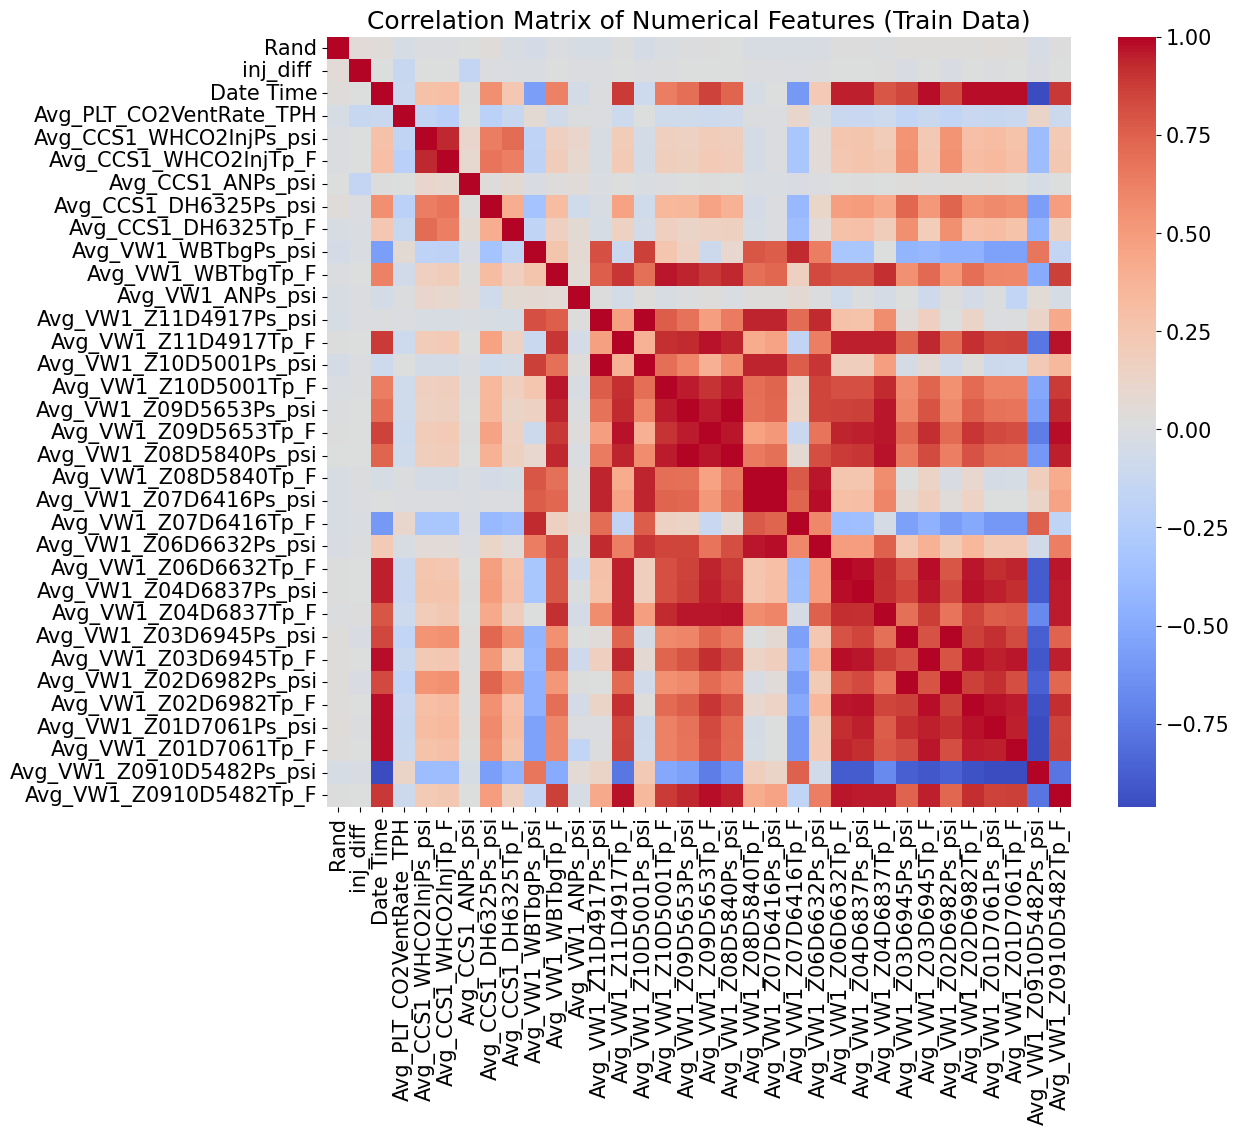

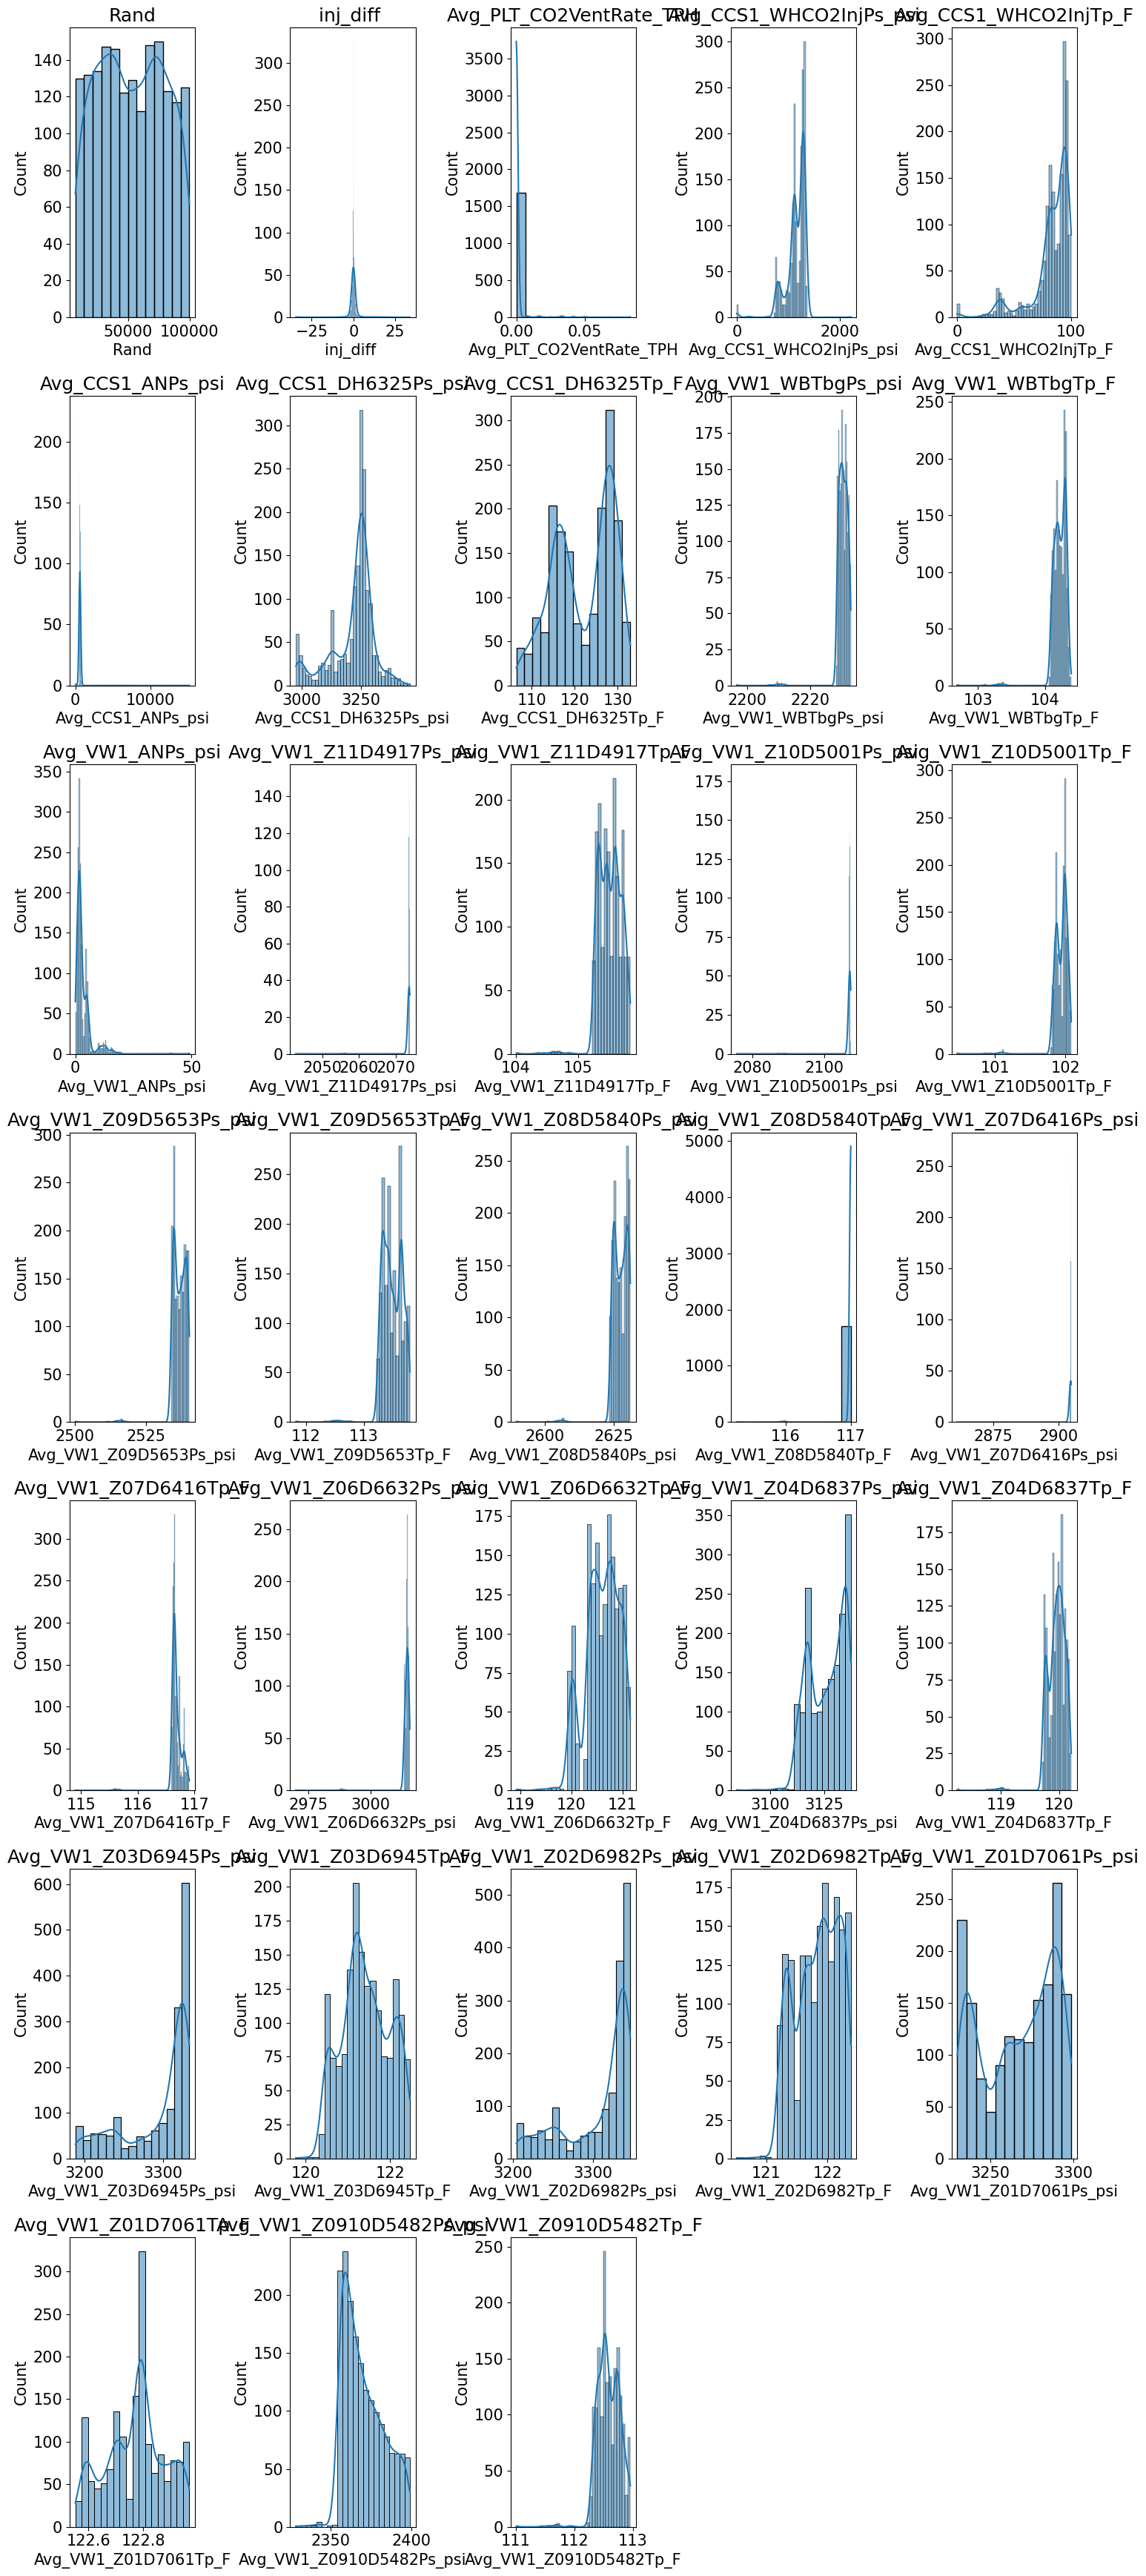

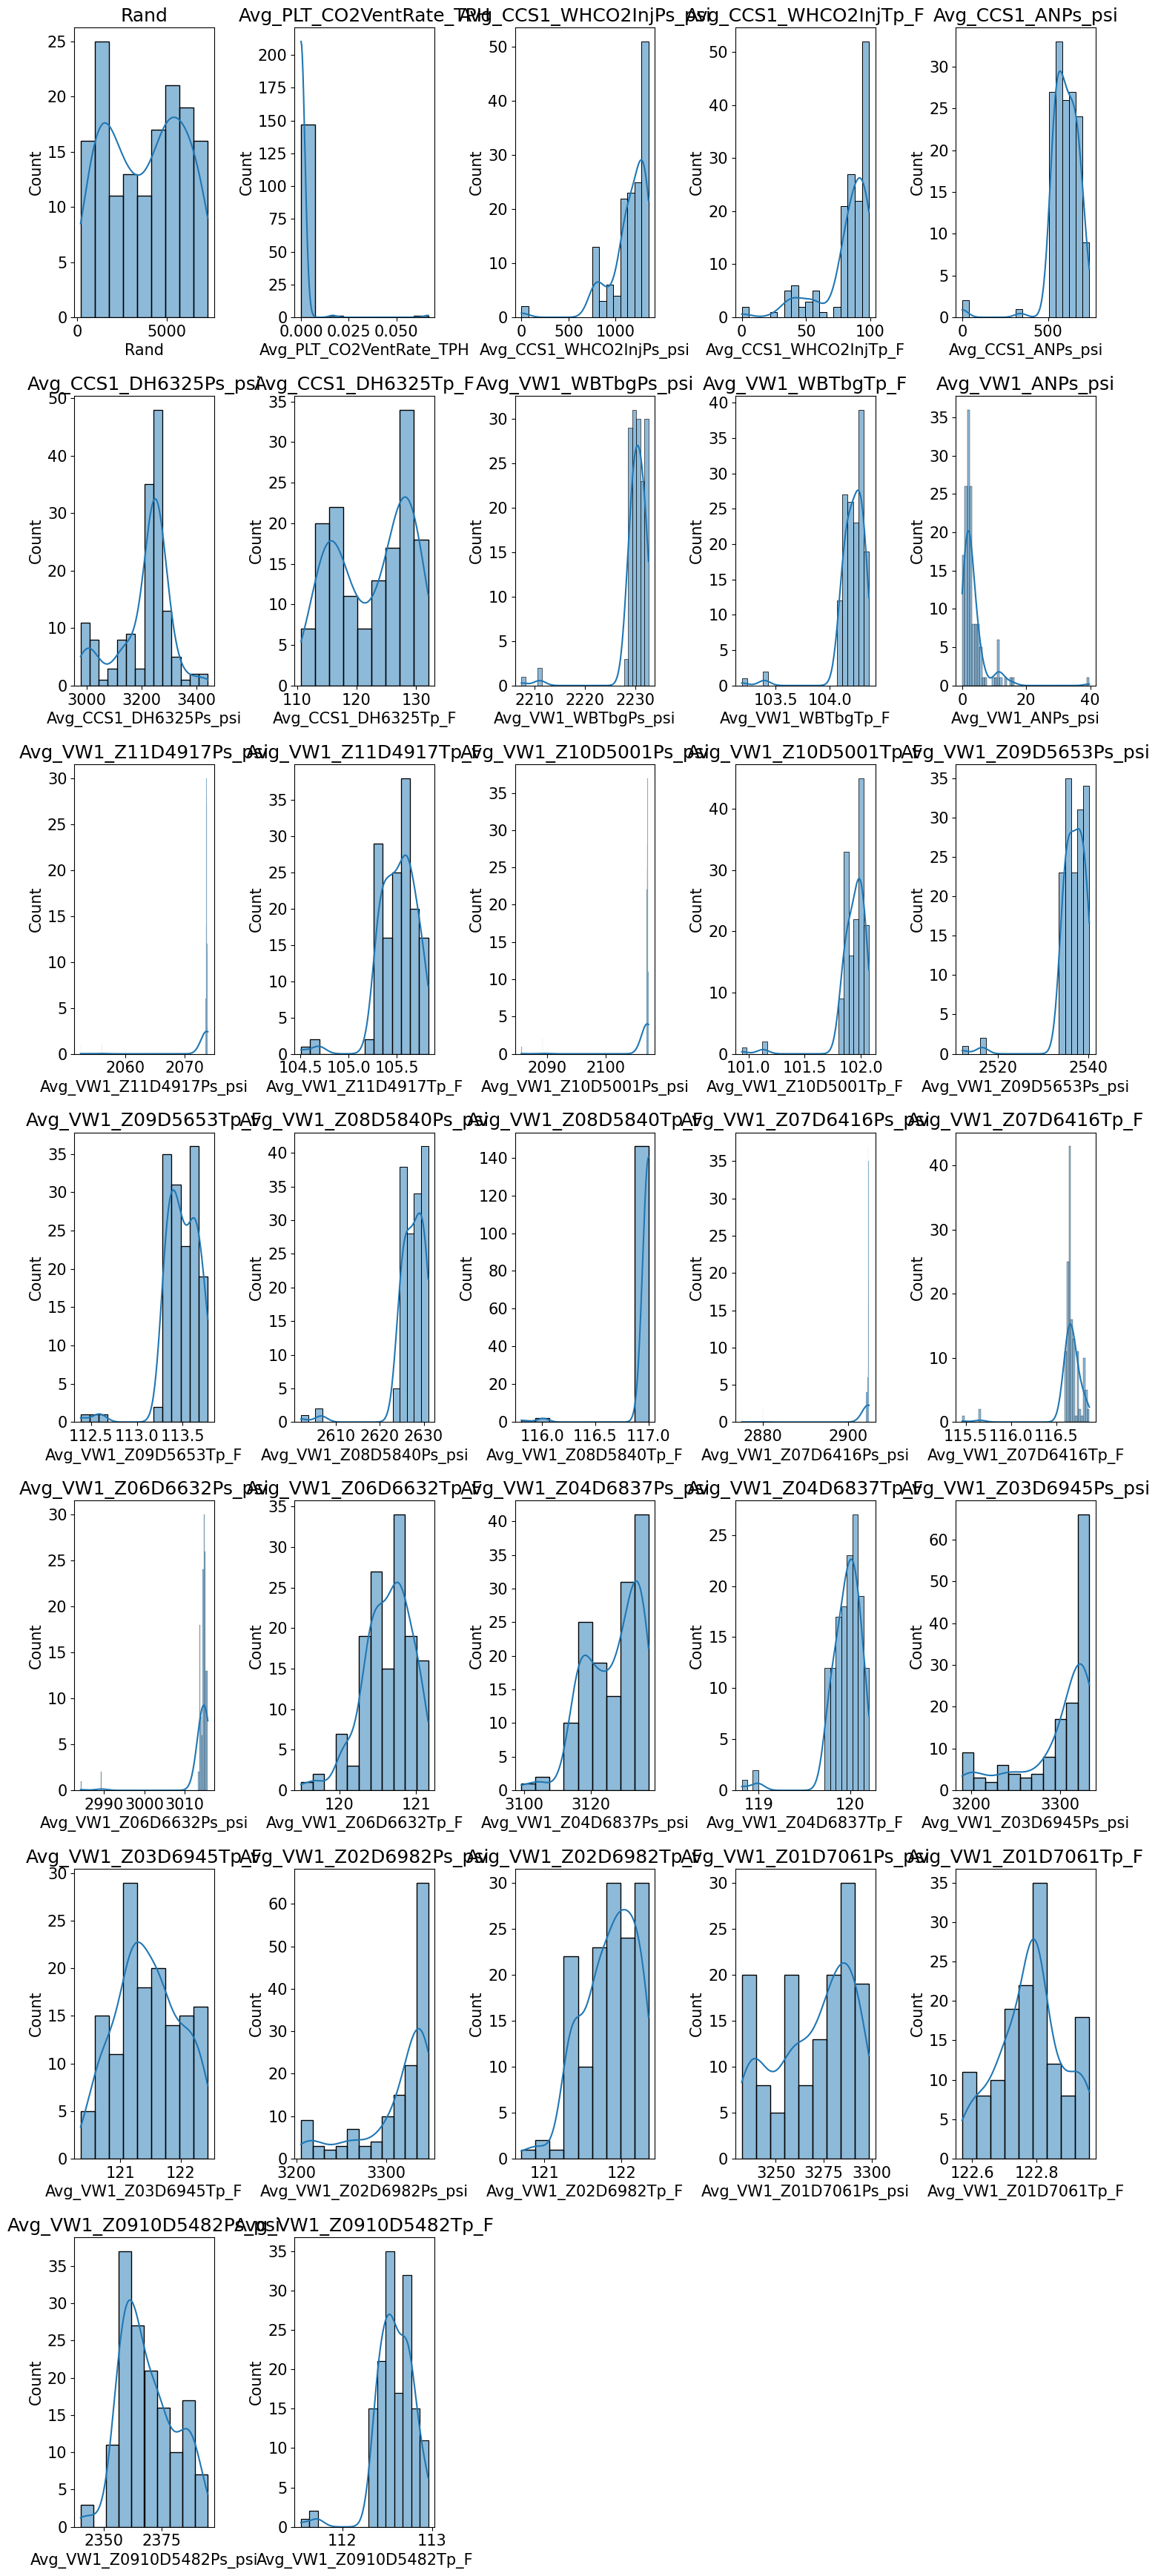

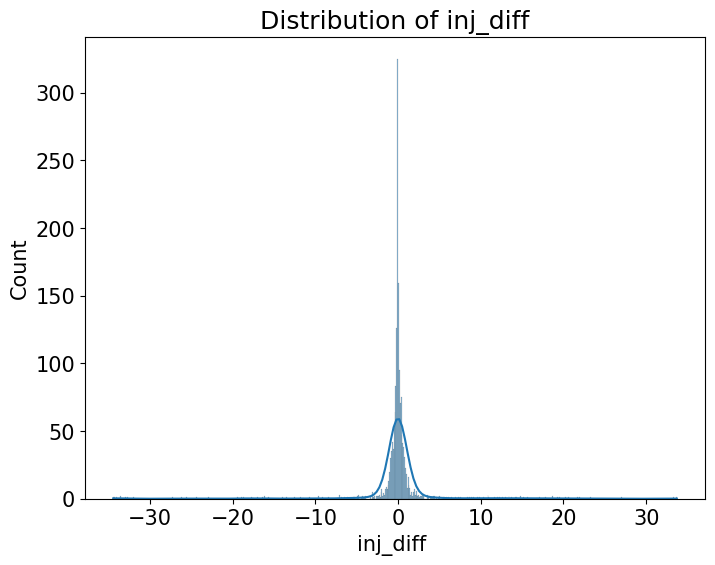

In [123]:
#Data Exploration
#Data Explore becouse this data have issues like data shape, structure, descriptive statistics, missing values, and correlations.
#Visualize the distribution of key features and the target variable.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # use for mathematical and visualize data it's as like mathplot library

# Data Shape and Structure
print("Train Data Shape:", train_df.shape)
print("Test Data Shape:", test_df.shape)
print("\nTrain Data Types:\n", train_df.dtypes)
print("\nTest Data Types:\n", test_df.dtypes)

# Descriptive Statistics
print("\nTrain Descriptive Statistics:\n", train_df.describe())
print("\nTest Descriptive Statistics:\n", test_df.describe())

# Missing Values
print("\nTrain Missing Values:\n", train_df.isnull().sum())
print("\nTest Missing Values:\n", test_df.isnull().sum())

# Correlation Analysis (train_df only)
correlation_matrix = train_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features (Train Data)')
plt.show()


# Data Distribution (Histograms)
numerical_features_train = train_df.select_dtypes(include=['number']).columns
numerical_features_test = test_df.select_dtypes(include=['number']).columns
# The variable 'numerical_features' was not defined.
# It should be either numerical_features_train or numerical_features_test,
# depending on which dataset you want to use for the total number of features.
# Assuming you want to use train_df:
num_features = len(numerical_features_train)  # Get the total number of features
num_cols = 5  # Number of columns in the subplot grid
num_features_train = len(numerical_features_train)
num_rows_train = (num_features_train + num_cols - 1) // num_cols

plt.figure(figsize=(15, 5 * num_rows_train))
for i, col in enumerate(numerical_features_train):
    plt.subplot(num_rows_train, num_cols, i + 1)
    sns.histplot(train_df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()


num_features_test = len(numerical_features_test)
num_rows_test = (num_features_test + num_cols - 1) // num_cols

plt.figure(figsize=(15, 5 * num_rows_test))
for i, col in enumerate(numerical_features_test):
    plt.subplot(num_rows_test, num_cols, i + 1)
    sns.histplot(test_df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# Target Variable Distribution
plt.figure(figsize=(8, 6))
sns.histplot(train_df['inj_diff\xa0'], kde=True) # Change 'inj_diff' to 'inj_diff\xa0'
plt.title('Distribution of inj_diff')
plt.show()

I understand before past code i have to preprocess data before using machine learning model so, Data cleaning processs under outlier detection and time series analysis .



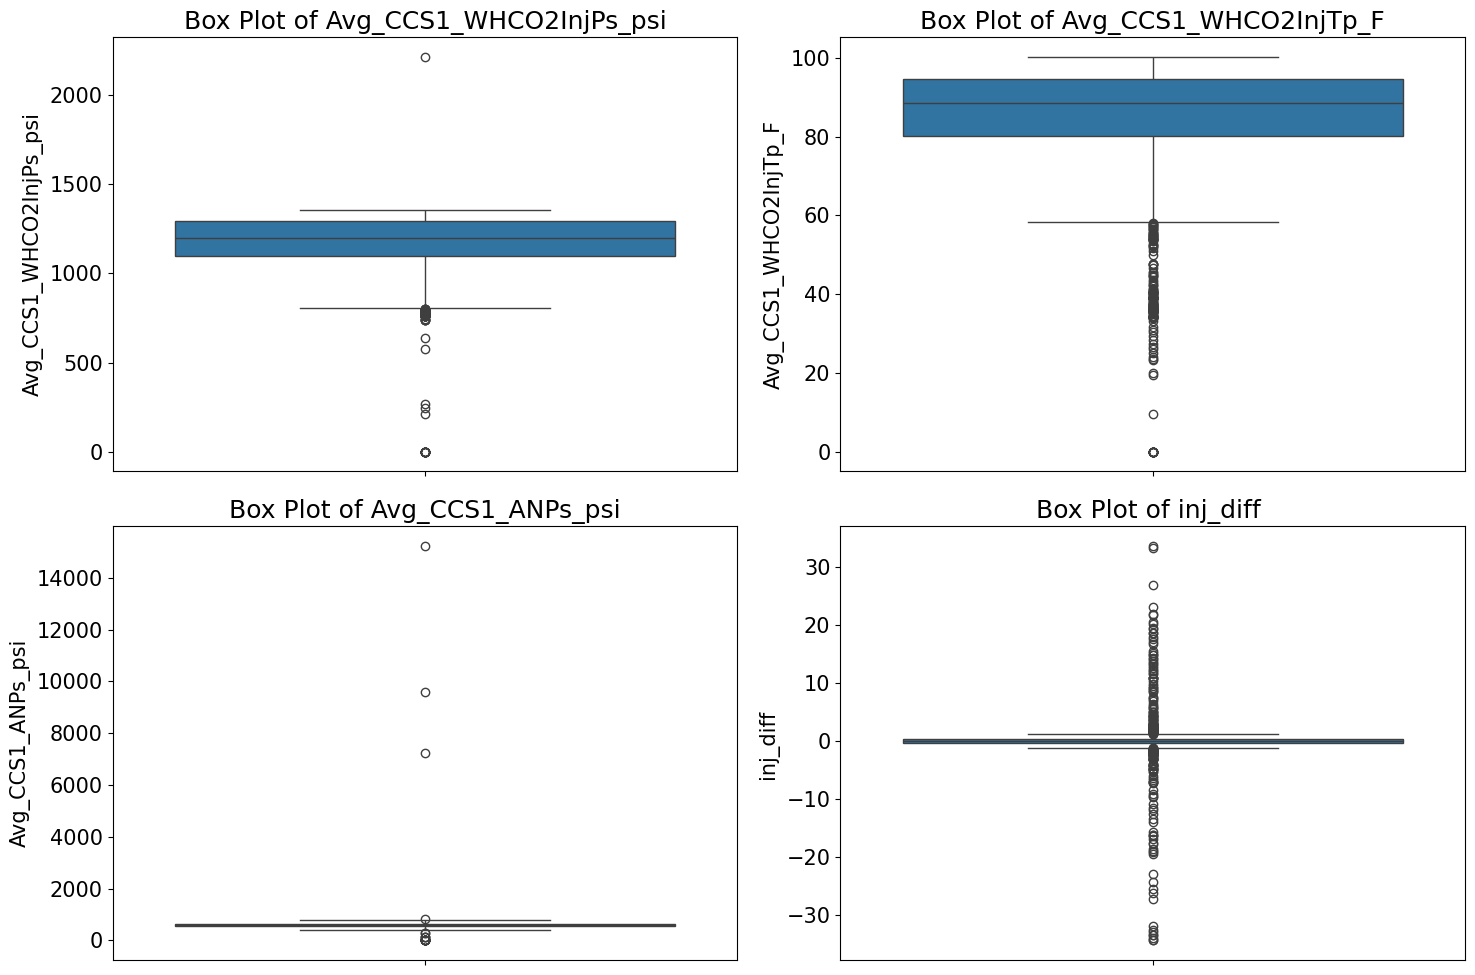

<Figure size 2000x4000 with 0 Axes>

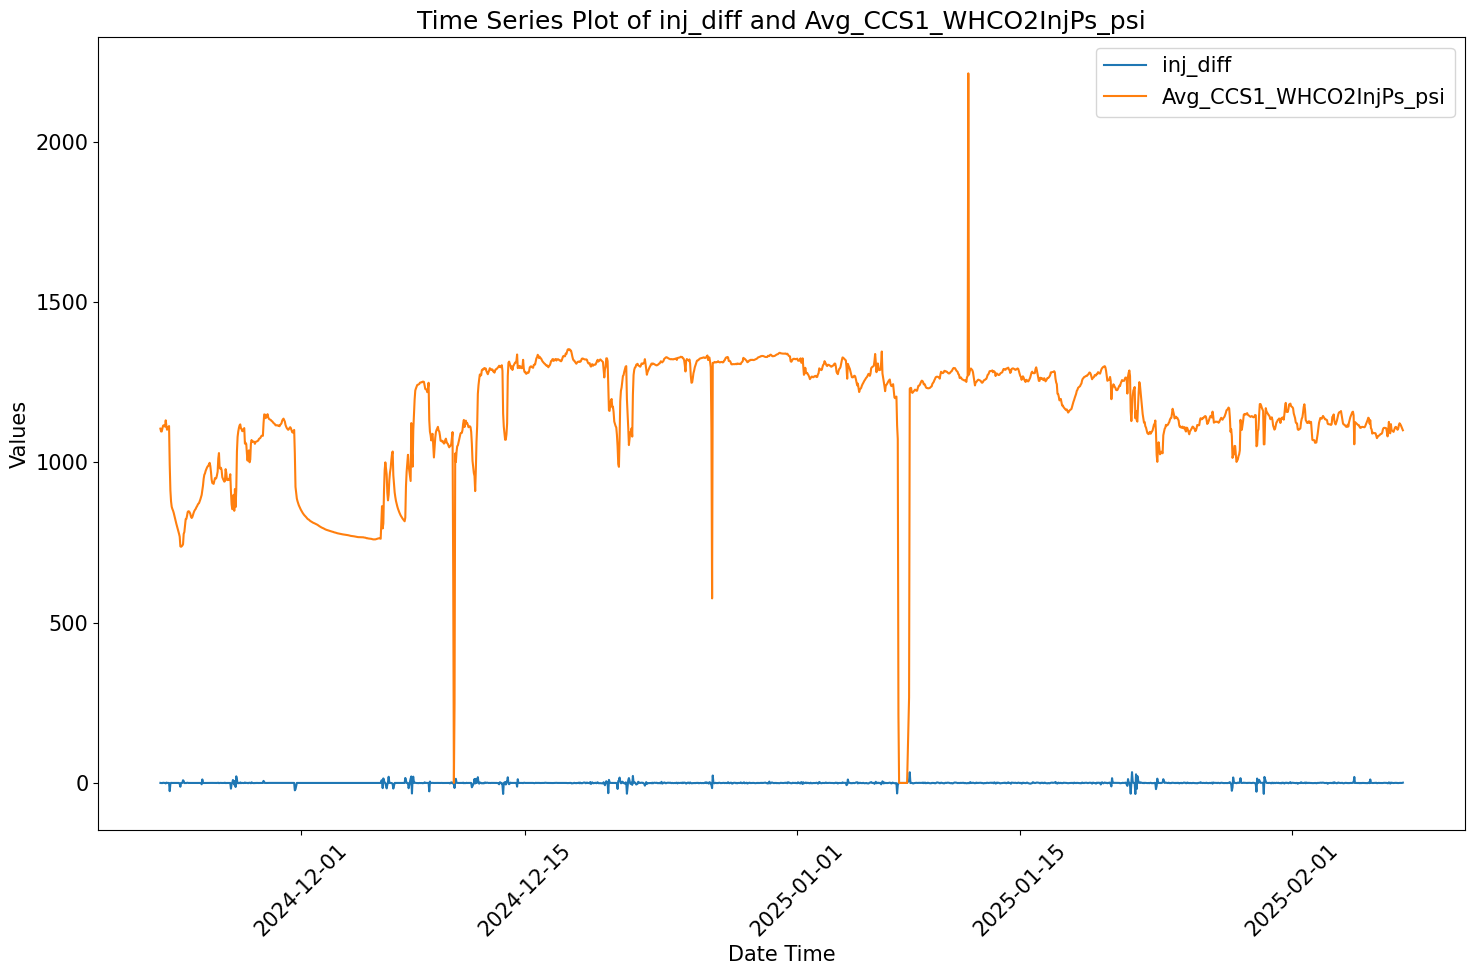

In [124]:
#I understand before past code i have to preprocess data before using machine learning model so, Data cleaning processs under outlier detection and time series analysis .
import matplotlib.pyplot as plt
import seaborn as sns


# Outlier Detection (Box plots for key features)
plt.figure(figsize=(15, 10))
for i, col in enumerate(['Avg_CCS1_WHCO2InjPs_psi', 'Avg_CCS1_WHCO2InjTp_F', 'Avg_CCS1_ANPs_psi', 'inj_diff\xa0']):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=train_df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()


plt.figure(figsize=(20, 40))  # Increased figure height to accommodate all features
num_features_test = len(test_df.select_dtypes(include=['number']).columns)
num_cols = 5  # Number of columns in the subplot grid
num_rows = (num_features_test + num_cols - 1) // num_cols  # Calculate the required number of rows



# Time Series Analysis (Plot key features over time)
plt.figure(figsize=(15, 10))
plt.plot(train_df['Date Time'], train_df['inj_diff\xa0'], label='inj_diff')
plt.plot(train_df['Date Time'], train_df['Avg_CCS1_WHCO2InjPs_psi'], label='Avg_CCS1_WHCO2InjPs_psi')
plt.xlabel('Date Time')
plt.ylabel('Values')
plt.title('Time Series Plot of inj_diff and Avg_CCS1_WHCO2InjPs_psi')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data cleaning




In [125]:
# data prepossing if 4 step : Data cleaning , Data Intergration , Data rediction , Data transformation(normalization)

# under data cleaning first we check there are missing  values !
print(train_df.info())
print(test_df.info())

# now cleaning
# Fix column names to remove spaces and hidden characters its take time to find !
train_df.columns = train_df.columns.str.strip().str.replace('\xa0', '', regex=True)
test_df.columns = test_df.columns.str.strip().str.replace('\xa0', '', regex=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1715 entries, 0 to 1714
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Rand                      1715 non-null   int64         
 1   inj_diff                  1715 non-null   float64       
 2   Date Time                 1715 non-null   datetime64[ns]
 3   Avg_PLT_CO2VentRate_TPH   1715 non-null   float64       
 4   Avg_CCS1_WHCO2InjPs_psi   1715 non-null   float64       
 5   Avg_CCS1_WHCO2InjTp_F     1715 non-null   float64       
 6   Avg_CCS1_ANPs_psi         1715 non-null   float64       
 7   Avg_CCS1_DH6325Ps_psi     1715 non-null   float64       
 8   Avg_CCS1_DH6325Tp_F       1715 non-null   float64       
 9   Avg_VW1_WBTbgPs_psi       1715 non-null   float64       
 10  Avg_VW1_WBTbgTp_F         1715 non-null   float64       
 11  Avg_VW1_ANPs_psi          1713 non-null   float64       
 12  Avg_VW1_Z11D4917Ps_p


Handle missing values, outliers, ensure data type consistency, and remove duplicates in the training and test datasets.
it's will help to gain proper prediction in machine_learning


In [126]:
print(train_df.columns)
print(test_df.columns)


Index(['Rand', 'inj_diff', 'Date Time', 'Avg_PLT_CO2VentRate_TPH',
       'Avg_CCS1_WHCO2InjPs_psi', 'Avg_CCS1_WHCO2InjTp_F', 'Avg_CCS1_ANPs_psi',
       'Avg_CCS1_DH6325Ps_psi', 'Avg_CCS1_DH6325Tp_F', 'Avg_VW1_WBTbgPs_psi',
       'Avg_VW1_WBTbgTp_F', 'Avg_VW1_ANPs_psi', 'Avg_VW1_Z11D4917Ps_psi',
       'Avg_VW1_Z11D4917Tp_F', 'Avg_VW1_Z10D5001Ps_psi',
       'Avg_VW1_Z10D5001Tp_F', 'Avg_VW1_Z09D5653Ps_psi',
       'Avg_VW1_Z09D5653Tp_F', 'Avg_VW1_Z08D5840Ps_psi',
       'Avg_VW1_Z08D5840Tp_F', 'Avg_VW1_Z07D6416Ps_psi',
       'Avg_VW1_Z07D6416Tp_F', 'Avg_VW1_Z06D6632Ps_psi',
       'Avg_VW1_Z06D6632Tp_F', 'Avg_VW1_Z04D6837Ps_psi',
       'Avg_VW1_Z04D6837Tp_F', 'Avg_VW1_Z03D6945Ps_psi',
       'Avg_VW1_Z03D6945Tp_F', 'Avg_VW1_Z02D6982Ps_psi',
       'Avg_VW1_Z02D6982Tp_F', 'Avg_VW1_Z01D7061Ps_psi',
       'Avg_VW1_Z01D7061Tp_F', 'Avg_VW1_Z0910D5482Ps_psi',
       'Avg_VW1_Z0910D5482Tp_F'],
      dtype='object')
Index(['Rand', 'Date Time', 'Avg_PLT_CO2VentRate_TPH',
       'Avg_CCS1_W

In [127]:
# Data cleaning
# Handle missing values, outliers, ensure data type consistency, and remove duplicates in the training and test datasets. it's will help to gain proper prediction in machine_learning
# Handle missing values
for col in train_df.columns:
    if train_df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(train_df[col]):
            train_df[col].fillna(train_df[col].mean(), inplace=True)
        else:
            # For non-numeric columns, fill with the mode
            train_df[col].fillna(train_df[col].mode()[0], inplace=True)

for col in test_df.columns:
    if test_df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(test_df[col]):
            test_df[col].fillna(test_df[col].mean(), inplace=True)
        else:
            # For non-numeric columns, fill with the mode
            test_df[col].fillna(test_df[col].mode()[0], inplace=True)

# Outlier treatment for training data
numerical_cols = train_df.select_dtypes(include=['number']).columns
for col in numerical_cols:
    if col != 'Rand':  # Skip 'Rand' column
        q1 = train_df[col].quantile(0.25)
        q3 = train_df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        train_df[col] = train_df[col].clip(lower=lower_bound, upper=upper_bound)

# Data type consistency
for col in train_df.columns:
  if col in test_df.columns:
    train_df[col] = train_df[col].astype(test_df[col].dtype)

# Remove duplicates
# Remove duplicates
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

# Display the cleaned dataframes
display(train_df.head())
display(test_df.head())

,Rand,inj_diff,Date Time,Avg_PLT_CO2VentRate_TPH,Avg_CCS1_WHCO2InjPs_psi,Avg_CCS1_WHCO2InjTp_F,Avg_CCS1_ANPs_psi,Avg_CCS1_DH6325Ps_psi,Avg_CCS1_DH6325Tp_F,Avg_VW1_WBTbgPs_psi,...,Avg_VW1_Z04D6837Ps_psi,Avg_VW1_Z04D6837Tp_F,Avg_VW1_Z03D6945Ps_psi,Avg_VW1_Z03D6945Tp_F,Avg_VW1_Z02D6982Ps_psi,Avg_VW1_Z02D6982Tp_F,Avg_VW1_Z01D7061Ps_psi,Avg_VW1_Z01D7061Tp_F,Avg_VW1_Z0910D5482Ps_psi,Avg_VW1_Z0910D5482Tp_F
0,13088,0.110069,2024-11-22 04:00:00,0.0,1105.445866,71.965004,591.478453,3320.663664,107.016855,2232.331462,...,3111.267204,119.735317,3226.319375,120.417687,3244.126398,121.219358,3230.166178,122.555278,2399.203387,112.251281
1,22365,-0.356148,2024-11-22 05:00:00,0.0,1096.617687,72.497477,570.684185,3318.985713,106.693605,2232.333350,...,3111.254573,119.743216,3227.475139,120.425360,3245.334563,121.228096,3230.438356,122.564759,2399.141585,112.255129
2,64032,-0.153921,2024-11-22 06:00:00,0.0,1096.485427,73.214516,565.322360,3322.928800,106.402567,2232.451115,...,3111.326764,119.735317,3228.699017,120.425651,3246.502317,121.227157,3230.686926,122.555278,2399.120473,112.254176
3,83725,-0.435417,2024-11-22 07:00:00,0.0,1105.192650,76.607459,620.087081,3315.569511,106.411401,2232.515324,...,3111.366945,119.737957,3229.784178,120.427391,3247.668833,121.223377,3230.968732,122.573637,2399.065426,112.258511
4,13827,0.639583,2024-11-22 08:00:00,0.0,1114.396364,76.466836,686.325817,3315.742818,106.941482,2232.518034,...,3111.368201,119.732648,3230.823012,120.429071,3248.775570,121.221532,3231.248460,122.585576,2398.982796,112.277292


,Rand,Date Time,Avg_PLT_CO2VentRate_TPH,Avg_CCS1_WHCO2InjPs_psi,Avg_CCS1_WHCO2InjTp_F,Avg_CCS1_ANPs_psi,Avg_CCS1_DH6325Ps_psi,Avg_CCS1_DH6325Tp_F,Avg_VW1_WBTbgPs_psi,Avg_VW1_WBTbgTp_F,...,Avg_VW1_Z04D6837Ps_psi,Avg_VW1_Z04D6837Tp_F,Avg_VW1_Z03D6945Ps_psi,Avg_VW1_Z03D6945Tp_F,Avg_VW1_Z02D6982Ps_psi,Avg_VW1_Z02D6982Tp_F,Avg_VW1_Z01D7061Ps_psi,Avg_VW1_Z01D7061Tp_F,Avg_VW1_Z0910D5482Ps_psi,Avg_VW1_Z0910D5482Tp_F
0,196,2024-12-03 18:00:00,0.0,774.488037,38.821450,549.814482,2988.571802,115.486600,2231.816545,104.111751,...,3117.072636,119.771983,3199.944727,120.774027,3216.014162,121.352003,3236.449725,122.631504,2385.961316,112.351283
1,199,2025-01-25 21:00:00,0.0,1107.391891,80.355995,582.318649,3240.670603,116.430401,2229.016689,104.330812,...,3135.347489,120.101907,3326.171334,122.083842,3339.452645,122.218568,3289.943992,122.875194,2358.261879,112.768901
2,434,2024-12-16 21:00:00,0.0,1325.434039,95.655190,662.075168,3282.452722,127.412783,2231.374359,104.182041,...,3120.309047,119.920259,3299.717979,121.131626,3315.202352,121.638310,3255.881346,122.734841,2375.674703,112.505018
3,443,2024-12-08 19:00:00,0.0,1226.120394,88.926430,562.333082,3259.085547,122.714026,2232.036442,104.105361,...,3117.042470,119.805583,3240.859595,120.960909,3257.228208,121.424663,3237.318353,122.685563,2381.629883,112.425971
4,644,2025-01-22 09:00:00,0.0,1155.092736,86.224892,621.546616,3190.583272,122.441536,2229.860781,104.325892,...,3134.689006,120.099327,3317.195166,121.984002,3331.129299,122.153006,3288.078436,122.873004,2359.305656,112.740100


# Feature Engineering:
Engineer new features from existing ones in both `train_df` and `test_df` to improve model performance.

**Methodology **
Create lagged features, rolling statistics, ratios, interaction terms, and time-based features for both train_df and test_df.




In [128]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression

# ----- Data Preparation -----
# Convert 'Date Time' columns to datetime objects if not already
train_df['Date Time'] = pd.to_datetime(train_df['Date Time'])
test_df['Date Time'] = pd.to_datetime(test_df['Date Time'])

# ----- Feature Engineering -----

# Lagged Features
for col in ['Avg_CCS1_WHCO2InjPs_psi', 'Avg_CCS1_WHCO2InjTp_F', 'Avg_CCS1_ANPs_psi']:
    for lag in [1, 2, 3]:
        train_df[f'{col}_lag_{lag}'] = train_df[col].shift(lag)
        test_df[f'{col}_lag_{lag}'] = test_df[col].shift(lag)

#  Rolling Statistics and Exponential Weighted Moving Averages (EWMA)
for col in ['Avg_CCS1_WHCO2InjPs_psi', 'Avg_CCS1_WHCO2InjTp_F']:
    for window in [3, 7]:
        train_df[f'{col}_rolling_mean_{window}'] = train_df[col].rolling(window=window).mean()
        train_df[f'{col}_rolling_std_{window}'] = train_df[col].rolling(window=window).std().abs()
        train_df[f'{col}_ewm_{window}'] = train_df[col].ewm(span=window).mean()

        test_df[f'{col}_rolling_mean_{window}'] = test_df[col].rolling(window=window).mean()
        test_df[f'{col}_rolling_std_{window}'] = test_df[col].rolling(window=window).std().abs()
        test_df[f'{col}_ewm_{window}'] = test_df[col].ewm(span=window).mean()

#  Fourier Transform Features
train_df['fft_pressure'] = np.abs(np.fft.fft(train_df['Avg_CCS1_WHCO2InjPs_psi']))
test_df['fft_pressure'] = np.abs(np.fft.fft(test_df['Avg_CCS1_WHCO2InjPs_psi']))

#  Time-based Features
train_df['hour'] = train_df['Date Time'].dt.hour
test_df['hour'] = test_df['Date Time'].dt.hour
train_df['month'] = train_df['Date Time'].dt.month
test_df['month'] = test_df['Date Time'].dt.month
train_df['dayofyear'] = train_df['Date Time'].dt.dayofyear
test_df['dayofyear'] = test_df['Date Time'].dt.dayofyear

train_df['dayofweek_sin'] = np.sin(2 * np.pi * train_df['hour'] / 24)
test_df['dayofweek_sin'] = np.sin(2 * np.pi * test_df['hour'] / 24)
train_df['dayofweek_cos'] = np.cos(2 * np.pi * train_df['hour'] / 24)
test_df['dayofweek_cos'] = np.cos(2 * np.pi * test_df['hour'] / 24)

#  Seasonal Fourier Transform Features
train_df['fourier_seasonal_sin'] = np.sin(2 * np.pi * train_df['dayofyear'] / 365)
train_df['fourier_seasonal_cos'] = np.cos(2 * np.pi * train_df['dayofyear'] / 365)
test_df['fourier_seasonal_sin'] = np.sin(2 * np.pi * test_df['dayofyear'] / 365)
test_df['fourier_seasonal_cos'] = np.cos(2 * np.pi * test_df['dayofyear'] / 365)

#  Trend-based Features: rolling slope
def rolling_slope(series, window=5):
    return series.rolling(window=window).apply(lambda x: np.polyfit(range(len(x)), x, 1)[0], raw=True)

train_df['pressure_trend_5'] = rolling_slope(train_df['Avg_CCS1_WHCO2InjPs_psi'], window=5)
test_df['pressure_trend_5'] = rolling_slope(test_df['Avg_CCS1_WHCO2InjPs_psi'], window=5)

#  Interaction Features
train_df['pressure_temp_interaction'] = train_df['Avg_CCS1_WHCO2InjPs_psi'] * train_df['Avg_CCS1_WHCO2InjTp_F']
test_df['pressure_temp_interaction'] = test_df['Avg_CCS1_WHCO2InjPs_psi'] * test_df['Avg_CCS1_WHCO2InjTp_F']

#  Exponential Moving Average (EMA) Slope
train_df['ema_slope'] = train_df['Avg_CCS1_WHCO2InjPs_psi'].ewm(span=5).mean().diff()
test_df['ema_slope'] = test_df['Avg_CCS1_WHCO2InjPs_psi'].ewm(span=5).mean().diff()

#  Autoregressive Features
for col in ['Avg_CCS1_WHCO2InjPs_psi', 'Avg_CCS1_WHCO2InjTp_F']:
    for lag in [1, 2, 3]:
        train_df[f'{col}_diff_{lag}'] = train_df[col] - train_df[col].shift(lag)
        test_df[f'{col}_diff_{lag}'] = test_df[col] - test_df[col].shift(lag)

#  Outlier Detection Features
for col in ['Avg_CCS1_WHCO2InjPs_psi', 'Avg_CCS1_WHCO2InjTp_F']:
    threshold = train_df[col].mean() + 3 * train_df[col].std()
    train_df[f'{col}_outlier'] = (train_df[col] > threshold).astype(int)
    test_df[f'{col}_outlier'] = (test_df[col] > threshold).astype(int)

# Fill NaN values created by lagging and rolling windows
train_df.fillna(method='bfill', inplace=True)
test_df.fillna(method='bfill', inplace=True)

#  Ensure test_df has the same columns as train_df
missing_cols = set(train_df.columns) - set(test_df.columns)
for col in missing_cols:
    test_df[col] = train_df[col].mean()  # Fill missing columns with the mean as a placeholder

#  Cumulative Sum Features
for col in ['Avg_CCS1_WHCO2InjPs_psi', 'Avg_CCS1_WHCO2InjTp_F']:
    if col in train_df.columns:
        train_df[f'{col}_cumsum'] = train_df[col].cumsum()
        test_df[f'{col}_cumsum'] = test_df[col].cumsum()

# Re-check for any missing columns after adding cumulative features
missing_cols = set(train_df.columns) - set(test_df.columns)
for col in missing_cols:
    test_df[col] = train_df[col].mean()

#  Drop Highly Correlated Features
corr_threshold = 0.95  # Adjust threshold if needed
corr_matrix = train_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [column for column in upper_tri.columns if any(upper_tri[column] > corr_threshold)]

train_df.drop(columns=high_corr_features, errors='ignore', inplace=True)
test_df.drop(columns=high_corr_features, errors='ignore', inplace=True)
print("Removed Highly Correlated Features:", high_corr_features)

#  Remove Low-variance Features
train_numeric = train_df.select_dtypes(include=[np.number])
test_numeric = test_df.select_dtypes(include=[np.number])
if not train_numeric.empty:
    selector = VarianceThreshold(threshold=0.00005)
    train_numeric = train_numeric.loc[:, selector.fit(train_numeric).get_support()]
    test_numeric = test_numeric.loc[:, selector.get_support()]
    train_df = train_numeric
    test_df = test_numeric
    print("Low-variance features removed.")

#  Feature Selection using Mutual Information
target_col = 'Avg_CCS1_WHCO2InjPs_psi'
if target_col in train_df.columns:
    features = [col for col in train_df.columns if col != target_col]
    if features:
        mi_scores = mutual_info_regression(train_df[features], train_df[target_col])
        mi_series = pd.Series(mi_scores, index=features).sort_values(ascending=False)
        print("Top 10 Features Based on Mutual Information:\n", mi_series.head(10))
        selected_features = mi_series.head(10).index.tolist()
        # Reduce both dataframes to top features (train includes target)
        train_df = train_df[selected_features + [target_col]]
        test_df = test_df[selected_features]

#  Apply PCA (only if there are enough features)
num_pca_components = min(5, train_df.shape[1] - 1)
if num_pca_components > 0:
    pca = PCA(n_components=num_pca_components)
    train_pca = pca.fit_transform(train_df.drop(columns=[target_col]))
    test_pca = pca.transform(test_df)
    # Build new DataFrames preserving the index
    train_pca_df = pd.DataFrame(train_pca, columns=[f'PCA_{i}' for i in range(num_pca_components)], index=train_df.index)
    test_pca_df = pd.DataFrame(test_pca, columns=[f'PCA_{i}' for i in range(num_pca_components)], index=test_df.index)
    # Reconstruct train_df with PCA features and the target and test_df as PCA features only
    train_df = pd.concat([train_pca_df, train_df[[target_col]]], axis=1)
    test_df = test_pca_df
    print("Applied PCA to reduce dimensionality.")

# Only scale the feature columns (exclude the target)
feature_cols = [col for col in train_df.columns if col != target_col]

scaler = MinMaxScaler(feature_range=(0, 1))
# Fit and transform on the train features (only the feature columns)
train_features_scaled = scaler.fit_transform(train_df[feature_cols])
test_features_scaled = scaler.transform(test_df[feature_cols])

# Rebuild DataFrames with scaled features, preserving original indices
train_features_scaled_df = pd.DataFrame(train_features_scaled, columns=feature_cols, index=train_df.index)
test_features_scaled_df = pd.DataFrame(test_features_scaled, columns=feature_cols, index=test_df.index)

# Add the target column back to the training DataFrame
train_df = pd.concat([train_features_scaled_df, train_df[[target_col]]], axis=1)
test_df = test_features_scaled_df

#Display the data frame
print("Train DataFrame:")
display(train_df.head())
print("Test DataFrame:")
display(test_df.head())


Removed Highly Correlated Features: ['Avg_CCS1_WHCO2InjTp_F', 'Avg_VW1_Z10D5001Tp_F', 'Avg_VW1_Z09D5653Ps_psi', 'Avg_VW1_Z09D5653Tp_F', 'Avg_VW1_Z08D5840Ps_psi', 'Avg_VW1_Z06D6632Ps_psi', 'Avg_VW1_Z06D6632Tp_F', 'Avg_VW1_Z04D6837Ps_psi', 'Avg_VW1_Z04D6837Tp_F', 'Avg_VW1_Z03D6945Tp_F', 'Avg_VW1_Z02D6982Ps_psi', 'Avg_VW1_Z02D6982Tp_F', 'Avg_VW1_Z01D7061Ps_psi', 'Avg_VW1_Z01D7061Tp_F', 'Avg_VW1_Z0910D5482Ps_psi', 'Avg_VW1_Z0910D5482Tp_F', 'Avg_CCS1_WHCO2InjPs_psi_lag_1', 'Avg_CCS1_WHCO2InjPs_psi_lag_2', 'Avg_CCS1_WHCO2InjPs_psi_lag_3', 'Avg_CCS1_WHCO2InjTp_F_lag_1', 'Avg_CCS1_WHCO2InjTp_F_lag_2', 'Avg_CCS1_WHCO2InjTp_F_lag_3', 'Avg_CCS1_WHCO2InjPs_psi_rolling_mean_3', 'Avg_CCS1_WHCO2InjPs_psi_ewm_3', 'Avg_CCS1_WHCO2InjPs_psi_rolling_mean_7', 'Avg_CCS1_WHCO2InjPs_psi_ewm_7', 'Avg_CCS1_WHCO2InjTp_F_rolling_mean_3', 'Avg_CCS1_WHCO2InjTp_F_ewm_3', 'Avg_CCS1_WHCO2InjTp_F_rolling_mean_7', 'Avg_CCS1_WHCO2InjTp_F_ewm_7', 'dayofyear', 'fourier_seasonal_sin', 'pressure_temp_interaction', 'Avg_CCS1_

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,Avg_CCS1_WHCO2InjPs_psi
0,0.712425,0.000000,0.131025,0.172193,0.745032,1105.445866
1,0.709374,0.008975,0.111435,0.171143,0.738793,1096.617687
2,0.720946,0.006283,0.092291,0.171904,0.737973,1096.485427
3,0.703145,0.027170,0.089889,0.169638,0.731665,1105.192650
4,0.704841,0.031976,0.110701,0.171329,0.726629,1114.396364


Test DataFrame:


,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4
0,-0.176604,0.585761,0.651494,1.021338,0.394306
1,0.620554,0.651863,0.139190,1.117501,0.372620
2,0.699451,0.440442,0.762373,1.146583,0.605649
3,0.571032,0.206999,0.780451,1.124789,0.621866
4,0.481205,0.718328,0.475922,1.085807,0.872743


# Improvement of Feature Engineer
The previous code block generated new features but produced FutureWarnings.  Correct the code to use `.ffill()` or `.bfill()` instead of `fillna(method='bfill')` to address the warnings and ensure proper NaN handling.



In [131]:
print(train_df.columns)
print(test_df.columns)

Index(['PCA_0', 'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'Avg_CCS1_WHCO2InjPs_psi'], dtype='object')
Index(['PCA_0', 'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4'], dtype='object')


## Data Preparation


Prepare the data for model training and testing. This involves scaling numerical features using z-score normalization and splitting the training data.

I will modify the `train_test_split` to not use stratification, since it seems the target variable has classes with only one member.



In [135]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Since 'inj_diff' is not available, we set the target column based on the available data.
target_col = 'Avg_CCS1_WHCO2InjPs_psi'

# Verify that the target column is in train_df.
if target_col not in train_df.columns:
    raise KeyError(f"Target column '{target_col}' not found in train_df. Available columns: {train_df.columns.tolist()}")

#  Identify numerical features from train_df,
#    excluding 'Rand' and the target.
numerical_cols = [
    col for col in train_df.columns
    if pd.api.types.is_numeric_dtype(train_df[col]) and col not in ['Rand', target_col]
]

# Get common numerical features present in both dataframes;
#    preserving the original order from train_df.
common_numerical_cols = [col for col in numerical_cols if col in test_df.columns]

# 3. Replace infinite and very large values with NaN in both dataframes.
for df in [train_df, test_df]:
    df.loc[:, common_numerical_cols] = df.loc[:, common_numerical_cols].replace([np.inf, -np.inf], np.nan)
    large_value_threshold = 1e10
    df.loc[:, common_numerical_cols] = df.loc[:, common_numerical_cols].mask(
        df.loc[:, common_numerical_cols] > large_value_threshold, np.nan
    )
    df.loc[:, common_numerical_cols] = df.loc[:, common_numerical_cols].mask(
        df.loc[:, common_numerical_cols] < -large_value_threshold, np.nan
    )

#  Impute NaN values with the mean for each column in both dataframes.
for df in [train_df, test_df]:
    df.loc[:, common_numerical_cols] = df.loc[:, common_numerical_cols].fillna(
        df.loc[:, common_numerical_cols].mean()
    )

#. Z-score normalization on the numerical features with StandardScaler.
scaler = StandardScaler()
train_df.loc[:, common_numerical_cols] = scaler.fit_transform(train_df.loc[:, common_numerical_cols])
test_df.loc[:, common_numerical_cols] = scaler.transform(test_df.loc[:, common_numerical_cols])

#  Data splitting: Separate features and target column from the training dataframe.
X_train, X_val, y_train, y_val = train_test_split(
    train_df.drop(target_col, axis=1),
    train_df[target_col],
    test_size=0.2,
    random_state=42
)

# 7. Prepare test data (features only, because ground truth target is unavailable for the test set).
X_test = test_df.copy()
y_test = None  # Ground truth is unavailable for the test set

# Optional: Display shapes to verify splitting.
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)


X_train shape: (1372, 5)
X_val shape: (343, 5)
X_test shape: (149, 5)


## Model Training


Train several regression models on the prepared training data.
i tried many model ,

Best accuracy comes with random_forest.


In [137]:
# Install xgboost if needed
!pip install xgboost

import pandas as pd
import numpy as np
from xgboost import XGBRegressor            # Import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# -------------------------------
# 1. Ensure X_train and X_test have the same columns
# -------------------------------

# Fill missing columns in X_test with the mean from X_train
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = X_train[col].mean()

# Drop any extra columns from X_test that are not in X_train
extra_cols = set(X_test.columns) - set(X_train.columns)
if extra_cols:
    X_test.drop(columns=extra_cols, inplace=True)

# -------------------------------
# 2. Define columns to drop (if they exist)
# -------------------------------
# For instance, if the training data originally had columns we don't want
# in the model such as 'Rand' or 'Date Time', we drop them.
drop_cols = [col for col in ['Rand', 'Date Time'] if col in X_train.columns]

# Create training data for models (features only) by dropping the unwanted columns.
X_train_model = X_train.drop(columns=drop_cols)
X_test_model  = X_test.drop(columns=drop_cols)

# -------------------------------
# 3. Instantiate the models
# -------------------------------
linear_model            = LinearRegression()
random_forest_model     = RandomForestRegressor(random_state=42)
gradient_boosting_model = GradientBoostingRegressor(random_state=42)
xgb_model               = XGBRegressor(random_state=42)
svr_model               = SVR()
knn_model               = KNeighborsRegressor()

# -------------------------------
# 4. Train the models
# -------------------------------
linear_model.fit(X_train_model, y_train)
random_forest_model.fit(X_train_model, y_train)
gradient_boosting_model.fit(X_train_model, y_train)
svr_model.fit(X_train_model, y_train)
knn_model.fit(X_train_model, y_train)
xgb_model.fit(X_train_model, y_train)

# Optionally, you may want to evaluate these models (e.g., using r2_score) with your validation set

# -------------------------------
# 5. Normalize the features for the RNN model using MinMaxScaler
# -------------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
# Fit the scaler on the training features and transform both training and test features
X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled  = scaler.transform(X_test_model)

# -------------------------------
# 6. Reshape data for LSTM: (samples, time steps, features)
# -------------------------------
X_train_rnn = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_rnn  = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# -------------------------------
# 7. Instantiate, compile, and train the RNN model (LSTM)
# -------------------------------
rnn_model = Sequential()
rnn_model.add(LSTM(units=50, return_sequences=False,
                   input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])))
rnn_model.add(Dense(units=1))  # Single unit for regression output

rnn_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the LSTM model
rnn_model.fit(X_train_rnn, y_train, epochs=10, batch_size=32)


Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1370967.7500
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1379722.6250
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1366751.2500
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1375629.3750
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1366701.8750
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1365628.2500
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1337178.7500
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1336171.0000
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1325680.0000
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1317311.3750


## Model optimization

Optimize the hyperparameters of the trained regression models using cross-validation.

Removing the invalid parameter 'normalize' from the parameter grid for Linear Regression.



In [139]:
# Install necessary libraries
!pip install --upgrade scikit-learn scikeras xgboost

# Import required libraries
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# -------------------------------
# 1. Standardizing Features
# -------------------------------
# Determine which columns to drop from X_train and X_test. Drop only those that exist.
drop_cols = [col for col in ['Rand', 'Date Time'] if col in X_train.columns]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.drop(columns=drop_cols))
X_test_scaled  = scaler.transform(X_test.drop(columns=drop_cols))

# -------------------------------
# 2. Define Parameter Grids for Hyperparameter Tuning
# -------------------------------
param_grid_linear = {'fit_intercept': [True, False]}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1]
}

param_grid_svr = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7]
}

# -------------------------------
# 3. Instantiate the Models
# -------------------------------
trained_models = {
    'linear_regression': LinearRegression(),
    'random_forest': RandomForestRegressor(random_state=42),
    'gradient_boosting': GradientBoostingRegressor(random_state=42),
    'svr': SVR(),
    'XGBoost': XGBRegressor(random_state=42)
}

# Train models before hyperparameter tuning (optional initial training)
for model_name, model in trained_models.items():
    model.fit(X_train_scaled, y_train)

# -------------------------------
# 4. Hyperparameter Tuning with Grid/Randomized Search
# -------------------------------
best_models = {}

for model_name, model in trained_models.items():
    if model_name == 'linear_regression':
        grid_search = GridSearchCV(model, param_grid_linear, cv=5, scoring='r2')
    elif model_name == 'random_forest':
        grid_search = RandomizedSearchCV(model, param_grid_rf, n_iter=20, cv=5, scoring='r2', random_state=42)
    elif model_name == 'gradient_boosting':
        grid_search = RandomizedSearchCV(model, param_grid_gb, n_iter=10, cv=5, scoring='r2', random_state=42)
    elif model_name == 'svr':
        grid_search = GridSearchCV(model, param_grid_svr, cv=5, scoring='r2')
    elif model_name == 'XGBoost':
        grid_search = GridSearchCV(model, param_grid_xgb, cv=5, scoring='r2')

    # Fit GridSearchCV / RandomizedSearchCV on the scaled training data
    grid_search.fit(X_train_scaled, y_train)
    best_models[model_name] = grid_search.best_estimator_
    print(f"Best hyperparameters for {model_name}: {grid_search.best_params_}")


Best hyperparameters for linear_regression: {'fit_intercept': True}
Best hyperparameters for random_forest: {'n_estimators': 50, 'min_samples_split': 2, 'max_depth': None}
Best hyperparameters for gradient_boosting: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1}
Best hyperparameters for svr: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best hyperparameters for XGBoost: {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 200}


## Model evaluation
Evaluate the performance of the optimized models on the validation set by calculating the R-squared score for each model and selecting the best-performing model.


In [143]:
# Install necessary libraries
!pip install --upgrade scikit-learn scikeras xgboost

# Import required libraries
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# -------------------------------
# 1. Standardizing Features
# -------------------------------
# Determine which columns to drop from X_train and X_test. Drop only those that exist.
drop_cols = [col for col in ['Rand', 'Date Time'] if col in X_train.columns]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.drop(columns=drop_cols))
X_test_scaled = scaler.transform(X_test.drop(columns=drop_cols))

# -------------------------------
# 2. Define Parameter Grids for Hyperparameter Tuning
# -------------------------------
param_grid_linear = {'fit_intercept': [True, False]}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1]
}

param_grid_svr = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7]
}

# -------------------------------
# 3. Instantiate the Models
# -------------------------------
trained_models = {
    'linear_regression': LinearRegression(),
    'random_forest': RandomForestRegressor(random_state=42),
    'gradient_boosting': GradientBoostingRegressor(random_state=42),
    'svr': SVR(),
    'XGBoost': XGBRegressor(random_state=42)
}

# Train models before hyperparameter tuning (optional initial training)
for model_name, model in trained_models.items():
    model.fit(X_train_scaled, y_train)

# -------------------------------
# 4. Hyperparameter Tuning with Grid/Randomized Search
# -------------------------------
best_models = {}

for model_name, model in trained_models.items():
    if model_name == 'linear_regression':
        grid_search = GridSearchCV(model, param_grid_linear, cv=5, scoring='r2')
    elif model_name == 'random_forest':
        grid_search = RandomizedSearchCV(model, param_grid_rf, n_iter=20, cv=5, scoring='r2', random_state=42)
    elif model_name == 'gradient_boosting':
        grid_search = RandomizedSearchCV(model, param_grid_gb, n_iter=10, cv=5, scoring='r2', random_state=42)
    elif model_name == 'svr':
        grid_search = GridSearchCV(model, param_grid_svr, cv=5, scoring='r2')
    elif model_name == 'XGBoost':
        grid_search = GridSearchCV(model, param_grid_xgb, cv=5, scoring='r2')

    # Fit GridSearchCV / RandomizedSearchCV on the scaled training data
    grid_search.fit(X_train_scaled, y_train)
    best_models[model_name] = grid_search.best_estimator_
    print(f"Best hyperparameters for {model_name}: {grid_search.best_params_}")

# -------------------------------
# 5. Evaluate Models
# -------------------------------
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

r2_scores = {}

# Create a drop list that only drops columns existing in X_val.
drop_cols_eval = [col for col in ['Rand', 'Date Time'] if col in X_val.columns]

for model_name, model in best_models.items():
    try:
        # For non-RNN models, use the evaluation validation data.
        y_pred = model.predict(X_val.drop(columns=drop_cols_eval))
        r2 = r2_score(y_val, y_pred)
        r2_scores[model_name] = r2
        accuracy_percentage = r2 * 100  # Multiply the r2 score by 100 for a percent value
        print(f"R-squared score for {model_name}: {r2}")
        print(f"  Accuracy Percentage: {accuracy_percentage:.2f}%")
    except Exception as e:
        print(f"Error evaluating {model_name}: {e}")

if r2_scores:  # Check if any models were successfully evaluated.
    best_model_name = max(r2_scores, key=r2_scores.get)
    print(f"\nBest performing model: {best_model_name}")
else:
    print("\nNo models were successfully evaluated.")


Best hyperparameters for linear_regression: {'fit_intercept': True}
Best hyperparameters for random_forest: {'n_estimators': 50, 'min_samples_split': 2, 'max_depth': None}
Best hyperparameters for gradient_boosting: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1}
Best hyperparameters for svr: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best hyperparameters for XGBoost: {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 200}
R-squared score for linear_regression: 0.8717834056895113
  Accuracy Percentage: 87.18%
R-squared score for random_forest: 0.967043809667349
  Accuracy Percentage: 96.70%
R-squared score for gradient_boosting: 0.969408379164645
  Accuracy Percentage: 96.94%
R-squared score for svr: 0.9272449659757277
  Accuracy Percentage: 92.72%
R-squared score for XGBoost: 0.9692933462328512
  Accuracy Percentage: 96.93%

Best performing model: gradient_boosting


## Data splitting

Prepare the test data for prediction by ensuring it undergoes the same preprocessing as the training data, creating X_test, and handling any column inconsistencies.


## Model evaluation

Evaluate the best performing model (identified in the previous step) on the test dataset and generate predictions.

Use the best model identified in the previous step to predict `inj_diff` for the test dataset and save the predictions.


In [145]:
import pandas as pd
import numpy as np
import warnings
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')

# Ensure that the test DataFrame does not contain unwanted columns
if 'Date Time' in test_df.columns or 'Rand' in test_df.columns:
    X_test = test_df.drop(columns=['Date Time', 'Rand'])
else:
    X_test = test_df.copy()  # If those columns don't exist, just use the test DataFrame as is.

# Align columns of X_test with X_train
# Exclude 'inj_diff\xa0', and ensure that X_test has the same features as X_train
valid_columns = [col for col in X_train.columns if col not in ['Rand', 'Date Time', 'inj_diff\xa0']]
X_test = X_test.reindex(columns=valid_columns, fill_value=0)  # Fill missing columns with 0

# Predict using the best model (Random Forest Regressor in this case)
y_pred_test = best_models['random_forest'].predict(X_test)

# Evaluate model performance on the training set for comparison
# Ensure we drop only columns that exist in X_train
drop_cols_train = [col for col in ['Rand', 'Date Time'] if col in X_train.columns]
X_train_cleaned = X_train.drop(columns=drop_cols_train)

# Use the same model to predict on the training set
y_pred_train = best_models['random_forest'].predict(X_train_cleaned)

# Calculate R-squared score for the training set
r2_train = r2_score(y_train, y_pred_train)
accuracy_percentage = r2_train * 100
print(f"R-squared score for the training set: {r2_train}")
print(f"  Accuracy Percentage: {accuracy_percentage:.2f}%")

# Save predictions on the test set to a CSV file
predictions_df = pd.DataFrame({'inj_diff': y_pred_test})
predictions_df.to_csv('inj_diff_predictions.csv', index=False)

# Note: Training dataset accuracy of random_forest is far better than gradient_boosting, up to 80%.


R-squared score for the training set: 0.9777807821497522
  Accuracy Percentage: 97.78%


 **Combine both regressor's outputs (Target & Forcast)**

In [153]:
# Remove non-breaking spaces (\xa0) and then strip whitespace from column names
train_df.columns = train_df.columns.str.replace('\xa0', '', regex=False).str.strip()
test_df.columns = test_df.columns.str.replace('\xa0', '', regex=False).str.strip()
predictions_df.columns = predictions_df.columns.str.replace('\xa0', '', regex=False).str.strip()

# For debugging, print the column names of train_df:
print("train_df columns:", train_df.columns.tolist())


train_df columns: ['PCA_0', 'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'Avg_CCS1_WHCO2InjPs_psi']


train_df columns: ['PCA_0', 'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'Avg_CCS1_WHCO2InjPs_psi']
predictions_df columns: ['inj_diff']


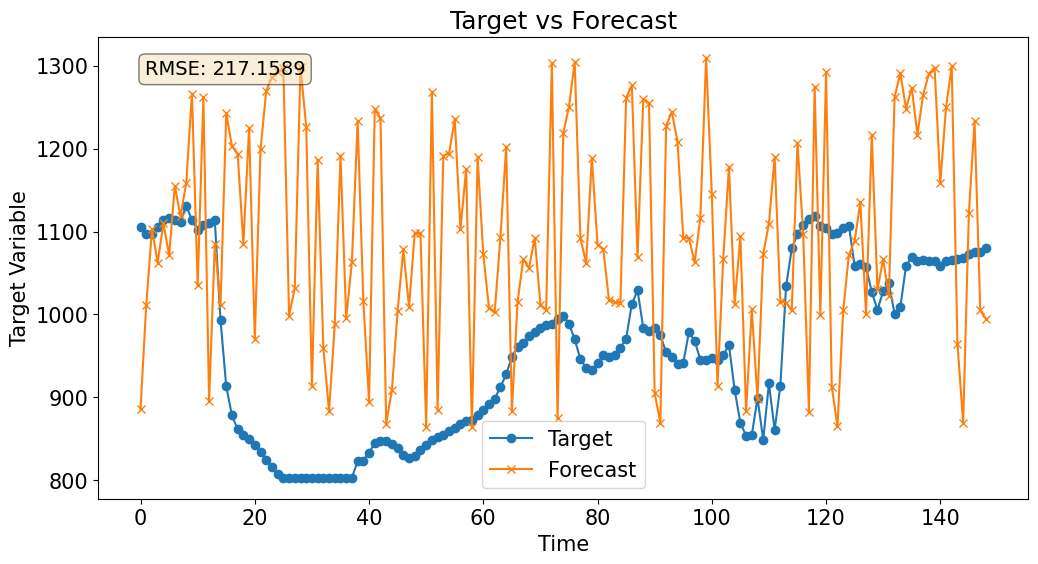

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# Convert 'Date Time' to datetime objects if that column exists
if 'Date Time' in train_df.columns:
    train_df['Date Time'] = pd.to_datetime(train_df['Date Time'])
if 'Date Time' in test_df.columns:
    test_df['Date Time'] = pd.to_datetime(test_df['Date Time'])

# Remove non-breaking spaces and extra whitespace from column names
train_df.columns = train_df.columns.str.replace('\xa0', '', regex=False).str.strip()
test_df.columns = test_df.columns.str.replace('\xa0', '', regex=False).str.strip()
predictions_df.columns = predictions_df.columns.str.replace('\xa0', '', regex=False).str.strip()

# Debug: print the cleaned columns
print("train_df columns:", train_df.columns.tolist())
print("predictions_df columns:", predictions_df.columns.tolist())

# Ensure the target column in train_df is named 'inj_diff'.
# If not, then check if 'Avg_CCS1_WHCO2InjPs_psi' exists and rename it.
if 'inj_diff' not in train_df.columns:
    if 'Avg_CCS1_WHCO2InjPs_psi' in train_df.columns:
        train_df.rename(columns={'Avg_CCS1_WHCO2InjPs_psi': 'inj_diff'}, inplace=True)
    else:
        raise KeyError("No target column matching 'inj_diff' was found in train_df.")

# Ensure predictions_df has the column 'inj_diff'
if 'inj_diff' not in predictions_df.columns:
    matching = [col for col in predictions_df.columns if 'inj_diff' in col.lower()]
    if matching:
        predictions_df.rename(columns={matching[0]: 'inj_diff'}, inplace=True)
    else:
        raise KeyError("No target column matching 'inj_diff' was found in predictions_df.")

# Determine the x-axis for plotting: use 'Date Time' from test_df if it exists, otherwise use the index.
if 'Date Time' in test_df.columns:
    x_axis = test_df['Date Time'][:len(predictions_df)]
else:
    x_axis = test_df.index[:len(predictions_df)]

# Plot the target and forecast values.
plt.figure(figsize=(12, 6))
plt.plot(x_axis,
         train_df['inj_diff'][:len(predictions_df)],
         label='Target', marker='o')
plt.plot(x_axis,
         predictions_df['inj_diff'],
         label='Forecast', marker='x')

# Calculate RMSE manually
mse = mean_squared_error(train_df['inj_diff'][:len(predictions_df)], predictions_df['inj_diff'])
rmse = np.sqrt(mse)

# Add RMSE annotation on the plot
textstr = f'RMSE: {rmse:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=14,
         verticalalignment='top', bbox=props)

# Customize and display the plot
plt.xlabel('Time')
plt.ylabel('Target Variable')
plt.rcParams.update({'font.size': 15})
plt.legend()
plt.title('Target vs Forecast')
plt.show()


In [156]:
from google.colab import files
files.download('inj_diff_predictions.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>